# Set Up
Import necessary packages, load and clean data

In [3]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# data cleaning/feature engineering
from sklearn.impute import SimpleImputer

## data cleaning
We are examining the datatypes in our data to determine if any additionally parsing or data handling is needed.  

It looks like most of our data types are objects or float64. We can leave the float64 as is, and convert the objects columns into string, binary, or a corresponding type.

looking at the dtypes values of the remaining string columns, it looks like a lot of them are categorical variables:
string variables categorized
- ordinal categoric will be numerically encoding
    - GeneralHealth, LastCheckupTime, HadDiabetes, SmokerStatus, ECigaretteUsage, CovidPos, TetanusLast10Tdap
    - numerical ranges --> take midpoint and convert to float64 
        - RemovedTeeth, AgeCategory
- nominal categoric --> leave as string and OHE if needed later
    - State, Sex, RaceEthnicityCategory

## Missingness Handling
Missingness imputation strategy

We will be inputing any numerical or numerically encoded column with the median, which is robust to outliers, and adding an additional column for feature_missing indicator. 

This will ensure that we are able to capture patterns shown in missingness in the missingness column and we are able to use the other columns in a model without encountering issues.

In [4]:
# data cleaning, missingness handling functions
def correcting_df_types(df):
    out = df.copy()
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            # print(f"{col} is numeric")
            pass
        elif df[col].dtype == 'object':
            out[col] = df[col].astype(str)
            values = set(df[col].astype(str).str.lower().str.strip().unique())
            if values <= {'yes', 'no', 'nan'}: # convert yes/no into bool
                out[col] = df[col].astype(str).str.lower()\
                    .str.strip().map({'yes': 1, 'no': 0, 'nan': np.nan})
            else:
                out[col] = df[col].astype(str)
                # print(f"-------- {col} --------")
                # print(f"type {df[col].dtype}")
                # print(f"converted from object to string")
                # print(f"examples: {', '.join(str(x) for x in df[col].unique())}")
                pass
        else:
            pass
            # print(f"-------- {col} --------")
            # print(f"type: {df[col].dtypes}")
            # print(f"examples: {', '.join(str(x) for x in df[col].unique()[:5])}")
    return out

def mapping_states_regions(df):
    out = df.copy()
    us_state_to_abbrev = {
        "Alabama": "AL",
        "Alaska": "AK",
        "Arizona": "AZ",
        "Arkansas": "AR",
        "California": "CA",
        "Colorado": "CO",
        "Connecticut": "CT",
        "Delaware": "DE",
        "District of Columbia": "DC",
        "Florida": "FL",
        "Georgia": "GA",
        "Hawaii": "HI",
        "Idaho": "ID",
        "Illinois": "IL",
        "Indiana": "IN",
        "Iowa": "IA",
        "Kansas": "KS",
        "Kentucky": "KY",
        "Louisiana": "LA",
        "Maine": "ME",
        "Maryland": "MD",
        "Massachusetts": "MA",
        "Michigan": "MI",
        "Minnesota": "MN",
        "Mississippi": "MS",
        "Missouri": "MO",
        "Montana": "MT",
        "Nebraska": "NE",
        "Nevada": "NV",
        "New Hampshire": "NH",
        "New Jersey": "NJ",
        "New Mexico": "NM",
        "New York": "NY",
        "North Carolina": "NC",
        "North Dakota": "ND",
        "Ohio": "OH",
        "Oklahoma": "OK",
        "Oregon": "OR",
        "Pennsylvania": "PA",
        "Rhode Island": "RI",
        "South Carolina": "SC",
        "South Dakota": "SD",
        "Tennessee": "TN",
        "Texas": "TX",
        "Utah": "UT",
        "Vermont": "VT",
        "Virginia": "VA",
        "Washington": "WA",
        "West Virginia": "WV",
        "Wisconsin": "WI",
        "Wyoming": "WY",
        
        # BRFSS territories
        "Guam": "GU",
        "Puerto Rico": "PR",
        "Virgin Islands": "VI",
    }
    state_to_region = {
        # Northeast
        "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast",
        "RI": "Northeast", "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",

        # Midwest
        "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest", "WI": "Midwest",
        "IA": "Midwest", "KS": "Midwest", "MN": "Midwest", "MO": "Midwest", "NE": "Midwest",
        "ND": "Midwest", "SD": "Midwest",

        # South
        "DE": "South", "FL": "South", "GA": "South", "MD": "South", "NC": "South",
        "SC": "South", "VA": "South", "DC": "South", "WV": "South",
        "AL": "South", "KY": "South", "MS": "South", "TN": "South",
        "AR": "South", "LA": "South", "OK": "South", "TX": "South",

        # West
        "AZ": "West", "CO": "West", "ID": "West", "MT": "West", "NV": "West",
        "NM": "West", "UT": "West", "WY": "West",
        "AK": "West", "CA": "West", "HI": "West",
        "OR": "West", "WA": "West",

        # Territory
        "GU": "Territory",
        "PR": "Territory",
        "VI": "Territory",

        # handling missing
        'missing': 'missing'
    }
    out['State'] = df['State'].map(us_state_to_abbrev)
    out['State'] = out['State'].fillna('missing') # handling missing
    out['Region'] = out['State'].map(state_to_region)
    return out

def mapping_categories(df):
    # converting string into int for ordinal cols, and keep as is for nominal cols
    # ============================================================
    # ORDINAL CATEGORICALS
    # ============================================================
    general_health_map = {
        "Excellent": 5,
        "Very good": 4,
        "Good": 3,
        "Fair": 2,
        "Poor": 1,
    }

    last_checkup_map = {
        "Within past year (anytime less than 12 months ago)": 0.5,
        "Within past 2 years (1 year but less than 2 years ago)": 1.5,
        "Within past 5 years (2 years but less than 5 years ago)": 3.5,
        "5 or more years ago": 7.5,
    }

    diabetes_map = {
        "No": 0,
        "No, pre-diabetes or borderline diabetes": 1,
        "Yes, but only during pregnancy (female)": 2,
        "Yes": 3,
    }

    smoker_map = {
        "Never smoked": 0,
        "Former smoker": 1,
        "Current smoker - now smokes some days": 2,
        "Current smoker - now smokes every day": 3,
    }

    ecig_map = {
        "Never used e-cigarettes in my entire life": 0,
        "Not at all (right now)": 1,
        "Use them some days": 2,
        "Use them every day": 3,
    }

    covid_map = {
        "No": 0,
        "Tested positive using home test without a health professional": 1,
        "Yes": 2,
    }

    # ============================================================
    # NUMERICAL RANGES -> MIDPOINTS
    # ============================================================

    age_map = {
        "Age 18 to 24": 21,
        "Age 25 to 29": 27,
        "Age 30 to 34": 32,
        "Age 35 to 39": 37,
        "Age 40 to 44": 42,
        "Age 45 to 49": 47,
        "Age 50 to 54": 52,
        "Age 55 to 59": 57,
        "Age 60 to 64": 62,
        "Age 65 to 69": 67,
        "Age 70 to 74": 72,
        "Age 75 to 79": 77,
        "Age 80 or older": 85,
    }

    removed_teeth_map = {
        "None of them": 0,
        "1 to 5": 3,
        "6 or more, but not all": 16,
        "All": 32,
    }

    # ============================================================
    # APPLY MAPPINGS
    # ============================================================
    out = df.copy()
    out["GeneralHealth"] = (
        df["GeneralHealth"]
        .map(general_health_map)
        .astype("float64")
    )

    out["LastCheckupTime"] = (
        df["LastCheckupTime"]
        .map(last_checkup_map)
        .astype("float64")
    )

    out["HadDiabetes"] = (
        df["HadDiabetes"]
        .map(diabetes_map)
        .astype("float64")
    )

    out["SmokerStatus"] = (
        df["SmokerStatus"]
        .map(smoker_map)
        .astype("float64")
    )

    out["ECigaretteUsage"] = (
        df["ECigaretteUsage"]
        .map(ecig_map)
        .astype("float64")
    )

    out["CovidPos"] = (
        df["CovidPos"]
        .map(covid_map)
        .astype("float64")
    )

    out["AgeCategory"] = (
        df["AgeCategory"]
        .map(age_map)
        .astype("float64")
    )

    out["RemovedTeeth"] = (
        df["RemovedTeeth"]
        .map(removed_teeth_map)
        .astype("float64")
    )

    # ============================================================
    # NOMINAL CATEGORICALS
    # leave as categorical for one-hot encoding later
    # ============================================================

    nominal_cols = [
        "State",
        "Region",
        "Sex",
        "RaceEthnicityCategory",
        "TetanusLast10Tdap"
    ]

    for col in nominal_cols:
        out[col] = df[col].astype("category").cat.add_categories(["missing"]).fillna("missing")
    return out

def handle_missing(df):
    out = df.copy()
    for col in out:
        if pd.api.types.is_numeric_dtype(out[col]):
            if out[col].isna().sum() != 0:
                missingness_indicator = col+'missing'
                # print(f'missineness {col} = {out[col].isna().sum()}')
                out[missingness_indicator] = out[col].isna()
                out[col] = out[col].fillna(out[col].median())
        elif isinstance(out[col], pd.CategoricalDtype):
            if "missing" not in out[col].cat.categories:
                out[col] = out[col].cat.add_categories(["missing"])
            out[col] = out[col].fillna("missing")
        else:
            # print(col)
            pass
    return out

In [5]:
# load dataset and clean
data = pd.read_csv('data/heart_2022_with_nans.csv')
data = data.dropna(subset=['HadHeartAttack']) # dropping all rows where target variable is missing
data = correcting_df_types(data)
data_states_mapped = mapping_states_regions(data)
data_ord_mapped = mapping_categories(data_states_mapped)
data_imputed = handle_missing(data_ord_mapped)
data_imputed.head(5)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,AgeCategorymissing,HeightInMetersmissing,WeightInKilogramsmissing,BMImissing,AlcoholDrinkersmissing,HIVTestingmissing,FluVaxLast12missing,PneumoVaxEvermissing,HighRiskLastYearmissing,CovidPosmissing
0,AL,Female,4.0,0.0,0.0,0.5,0.0,8.0,0.0,0.0,...,False,True,True,True,False,False,False,False,False,False
1,AL,Female,5.0,0.0,0.0,0.5,0.0,6.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,AL,Female,4.0,2.0,3.0,0.5,1.0,5.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,AL,Female,5.0,0.0,0.0,0.5,1.0,7.0,0.0,0.0,...,True,False,False,False,False,False,False,False,False,False
4,AL,Female,2.0,2.0,0.0,0.5,1.0,9.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


# EDA

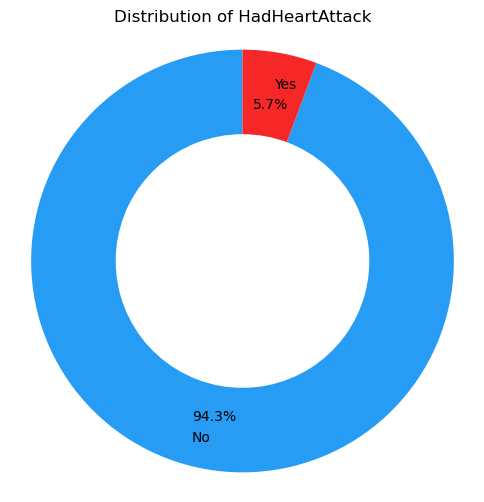

In [6]:
# inspecting target distribution
heart_attack_counts = data_imputed['HadHeartAttack'].value_counts(normalize=False)

plt.figure(figsize=(6, 6))

plt.pie(
    heart_attack_counts,
    labels=["No", "Yes"],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4},
    labeldistance=0.85,   # class labels
    pctdistance=0.75,      # percentages
    colors=["#279CF5", "#F52727"]
)

plt.title('Distribution of HadHeartAttack')
plt.axis('equal')
plt.show()

## Examining States Feature

In [7]:
state_rates = (
    data_imputed.groupby("State", observed=False)["HadHeartAttack"]
    .agg(heart_attack_rate="mean", count="count")
    .reset_index()
)
state_rates["heart_attack_rate"] *= 100

state_rates = state_rates.sort_values('heart_attack_rate', ascending=False).reset_index(drop=True)
fig = px.choropleth(
    state_rates,
    locations="State",
    locationmode="USA-states",
    color="heart_attack_rate",
    scope="usa",
    color_continuous_scale="Reds",
    labels={
        "heart_attack_rate": "Heart Attack Rate (%)"
    },
    title="Heart Attack Prevalence by State"
)

fig.show()

fig = px.choropleth(
    state_rates,
    locations="State",
    locationmode="USA-states",
    color="count",
    scope="usa",
    color_continuous_scale="Blues",
    labels={
        "count": "count"
    },
    title="Number of data entries by State"
)

fig.show()

In [8]:
# looking at regions
state_to_region = {
    # Northeast
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast",
    "RI": "Northeast", "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",

    # Midwest
    "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest", "WI": "Midwest",
    "IA": "Midwest", "KS": "Midwest", "MN": "Midwest", "MO": "Midwest", "NE": "Midwest",
    "ND": "Midwest", "SD": "Midwest",

    # South
    "DE": "South", "FL": "South", "GA": "South", "MD": "South", "NC": "South",
    "SC": "South", "VA": "South", "DC": "South", "WV": "South",
    "AL": "South", "KY": "South", "MS": "South", "TN": "South",
    "AR": "South", "LA": "South", "OK": "South", "TX": "South",

    # West
    "AZ": "West", "CO": "West", "ID": "West", "MT": "West", "NV": "West",
    "NM": "West", "UT": "West", "WY": "West",
    "AK": "West", "CA": "West", "HI": "West",
    "OR": "West", "WA": "West"
}

state_rates["Region"] = state_rates["State"].map(state_to_region)
fig = px.choropleth(
    state_rates,
    locations="State",          # state abbreviations (CA, TX, etc.)
    locationmode="USA-states",
    color="Region",            # color by region instead of numeric value
    scope="usa",
    hover_data={
        "heart_attack_rate": ":.2%",
        "Region": True,
    },
    title="Heart Attack Rate by State (Colored by Region)"
)

fig.update_layout(
    geo=dict(showlakes=True),
)

fig.show()


/var/folders/d2/b6r3bd092gd64r62_0p_5mbm0000gn/T/ipykernel_65223/2210962436.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


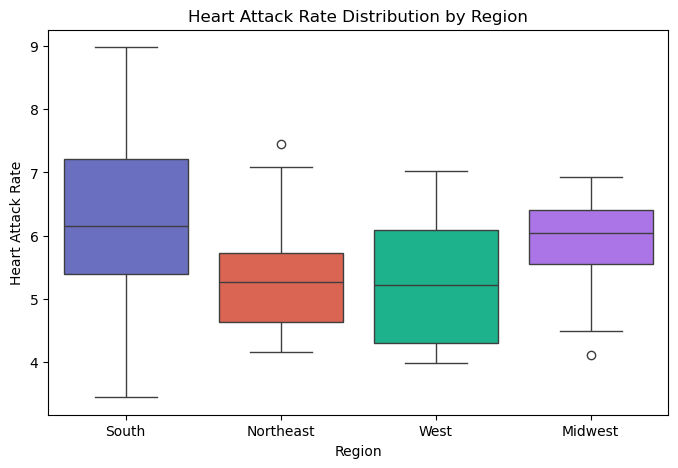

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=state_rates,
    x="Region",
    y="heart_attack_rate",
    palette=['#5C63CD', '#EF553B', '#04CB97', '#AA62FA']
)

plt.title("Heart Attack Rate Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Heart Attack Rate")

plt.show()

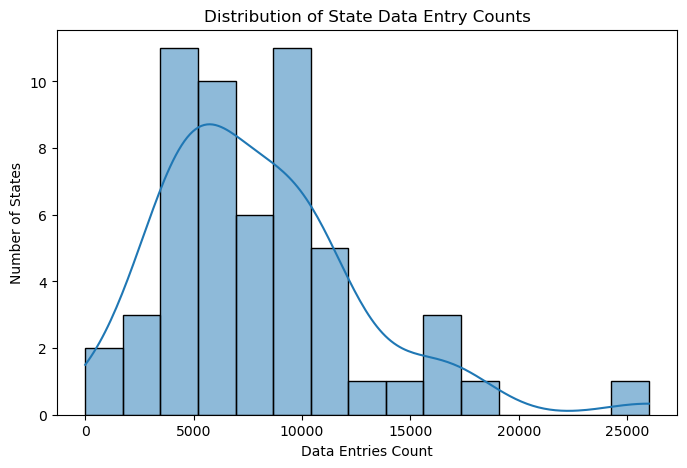

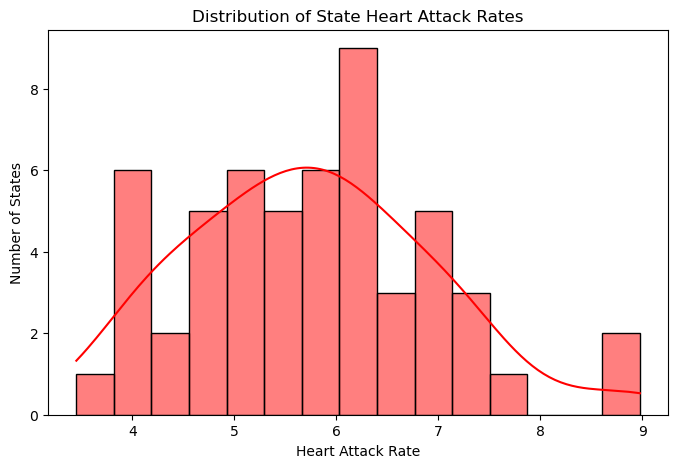

In [10]:
# state counts and rats histogram
plt.figure(figsize=(8,5))

sns.histplot(state_rates["count"], bins=15, kde=True)

plt.title("Distribution of State Data Entry Counts")
plt.xlabel("Data Entries Count")
plt.ylabel("Number of States")

plt.show()

plt.figure(figsize=(8,5))

sns.histplot(state_rates["heart_attack_rate"], bins=15, kde=True, color='red')

plt.title("Distribution of State Heart Attack Rates")
plt.xlabel("Heart Attack Rate")
plt.ylabel("Number of States")

plt.show()

Text(0.5, 1.0, 'Heart Attack Rates vs Number of Data Entries (by State)')

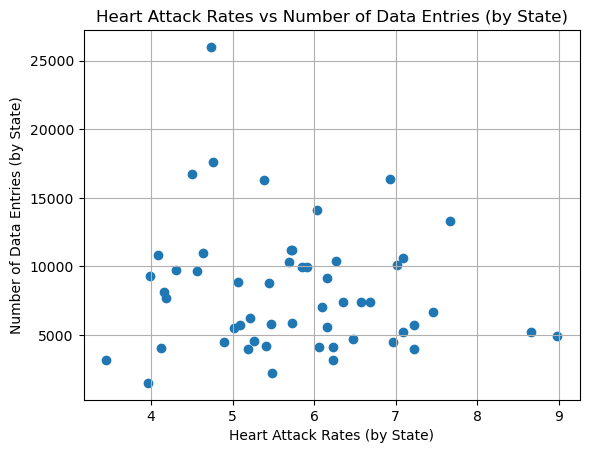

In [11]:
plt.scatter(x=state_rates["heart_attack_rate"], y=state_rates["count"])
plt.grid(visible=True, which='major')
plt.xlabel('Heart Attack Rates (by State)')
plt.ylabel('Number of Data Entries (by State)')
plt.title('Heart Attack Rates vs Number of Data Entries (by State)')

## Categorical, Continous, and Missingness Column Analysis

In [55]:
categorical_cols = ['State', 'Sex', 'GeneralHealth', 'LastCheckupTime', 'PhysicalActivities',
       'RemovedTeeth', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 
       'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 
       'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap',
       'HighRiskLastYear', 'CovidPos']

continuous_cols = ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 
                  'HeightInMeters', 'WeightInKilograms', 'BMI']

missingness_cols = ['GeneralHealthmissing', 'PhysicalHealthDaysmissing', 
                    'MentalHealthDaysmissing', 'LastCheckupTimemissing', 
                    'PhysicalActivitiesmissing', 'SleepHoursmissing',
                    'RemovedTeethmissing', 'HadAnginamissing','HadStrokemissing', 
                    'HadAsthmamissing', 'HadSkinCancermissing', 'HadCOPDmissing', 
                    'HadDepressiveDisordermissing', 'HadKidneyDiseasemissing', 
                    'HadArthritismissing', 'HadDiabetesmissing', 
                    'DeafOrHardOfHearingmissing', 'BlindOrVisionDifficultymissing',
                    'DifficultyConcentratingmissing', 'DifficultyWalkingmissing',
                    'DifficultyDressingBathingmissing', 'DifficultyErrandsmissing',
                    'SmokerStatusmissing', 'ECigaretteUsagemissing', 'ChestScanmissing',
                    'AgeCategorymissing', 'HeightInMetersmissing','WeightInKilogramsmissing', 
                    'BMImissing', 'AlcoholDrinkersmissing', 'HIVTestingmissing', 
                    'FluVaxLast12missing', 'PneumoVaxEvermissing',
                    'HighRiskLastYearmissing', 'CovidPosmissing']

binary_cols = ['PhysicalActivities', 'HadHeartAttack', 'HadAngina', 'HadStroke',
       'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder',
       'HadKidneyDisease', 'HadArthritis', 'DeafOrHardOfHearing',
       'BlindOrVisionDifficulty', 'DifficultyConcentrating',
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands',
       'ChestScan', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12',
       'PneumoVaxEver', 'HighRiskLastYear']

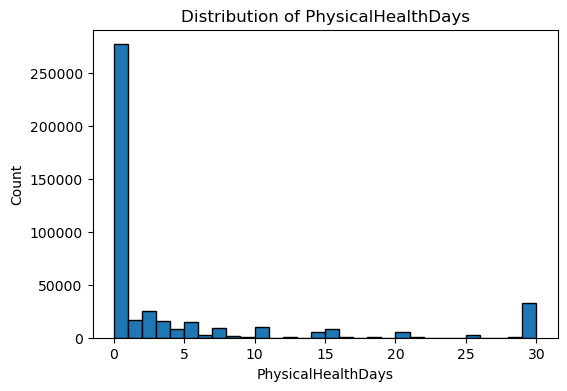

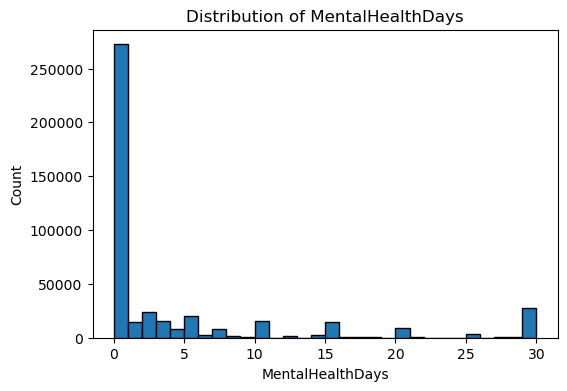

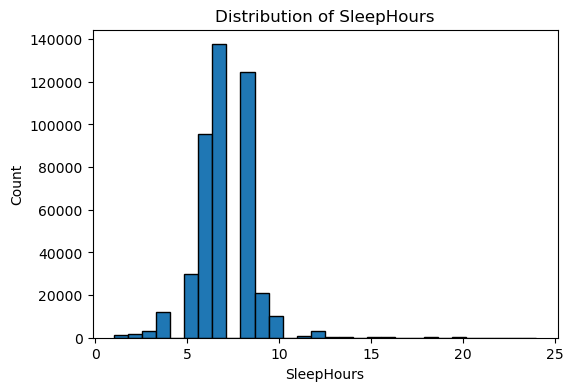

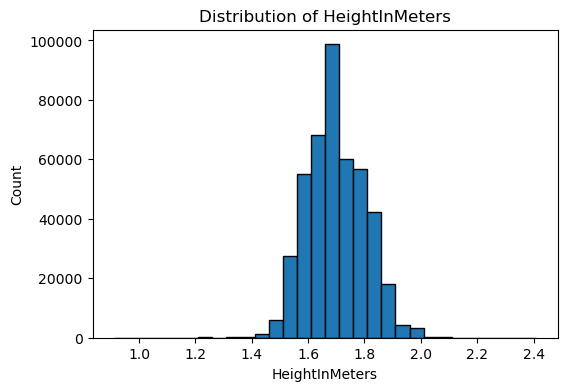

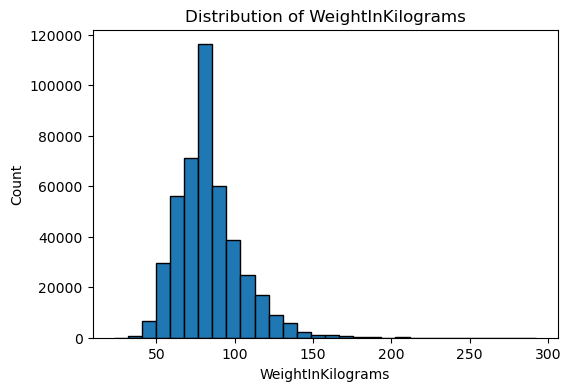

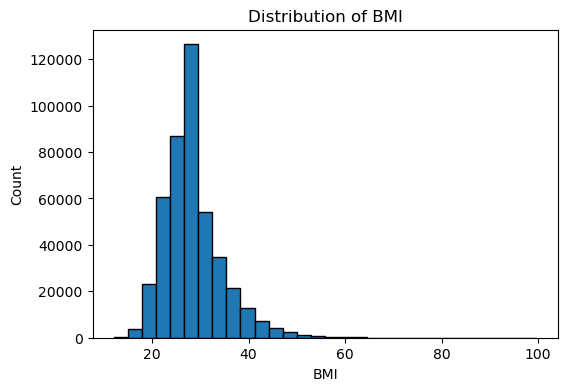

In [ ]:
# Histograms for continuous variables
for col in continuous_cols:
    plt.figure(figsize=(6, 4))

    plt.hist(
        data_imputed[col].dropna(),
        bins=30,
        edgecolor='black'
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

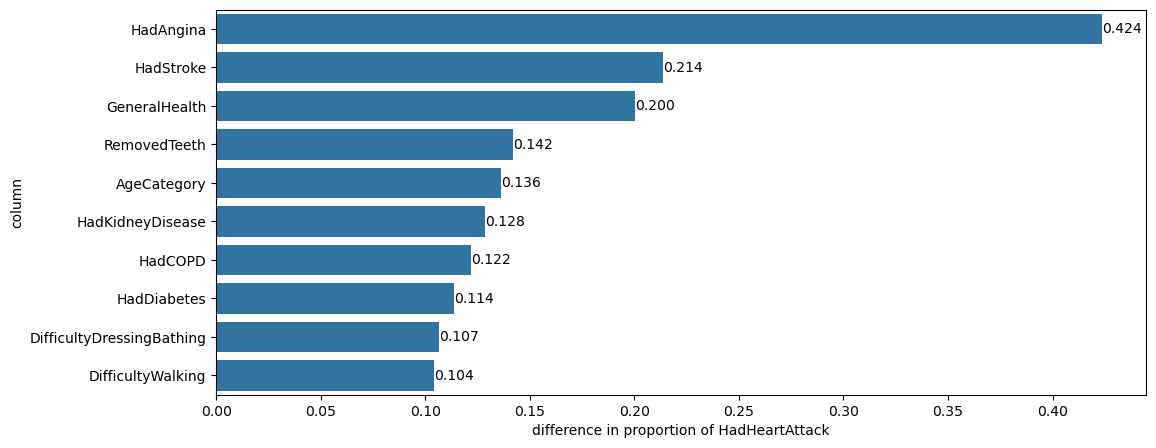

In [14]:
# features with max proportion differences greater than 0.10 across categories
diff_greater_than_10 = {}
for col in categorical_cols:
    grouped_proportions = data_imputed.groupby(col, observed=False)["HadHeartAttack"]\
        .apply(lambda x: (x == 1).mean()).sort_values()
    diff = grouped_proportions.iloc[-1] - grouped_proportions.iloc[0]
    
    
    if diff > 0.10:
        # print(f"{col} difference = {diff}")
        # sns.histplot(
        #     data=data_imputed,
        #     x=col,
        #     hue="HadHeartAttack",
        #     stat="density",
        #     common_norm=False
        # )
        diff_greater_than_10[col] = diff

proportion_diff_df = (
    pd.Series(diff_greater_than_10, name="difference in proportion of HadHeartAttack")
      .rename_axis("column")
      .reset_index()
      .sort_values("difference in proportion of HadHeartAttack", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    y='column',
    x='difference in proportion of HadHeartAttack',
    data=proportion_diff_df,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')  # 3 decimal places
# plt.xticks(rotation=10, ha='right')  # tilt labels
# plt.tight_layout()                   # prevent cutoff
plt.show()

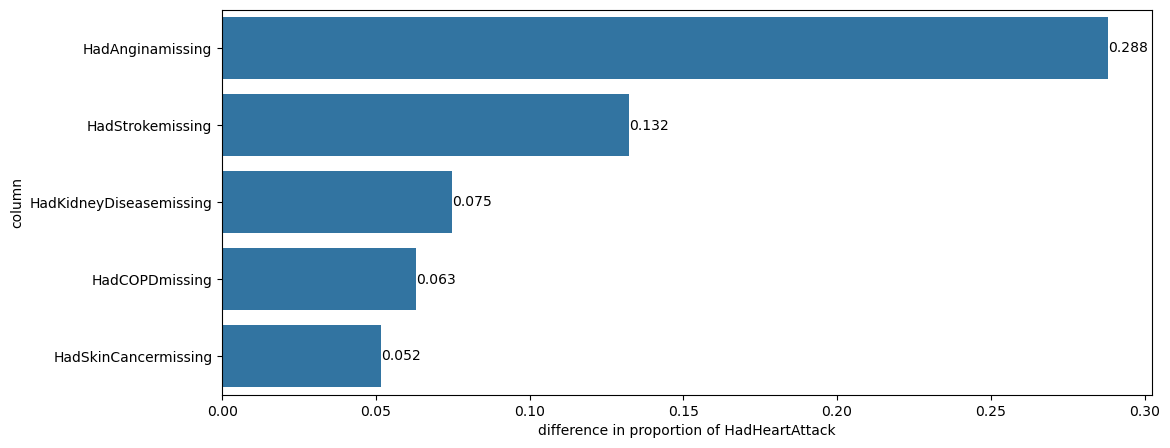

In [15]:
# missingness 
diff_greater_than_5 = {}

for col in missingness_cols:
    grouped_proportions = data_imputed.groupby(col, observed=False)["HadHeartAttack"]\
        .apply(lambda x: (x == 1).mean()).sort_values()
    diff = grouped_proportions.iloc[-1] - grouped_proportions.iloc[0]
    
    
    if diff > 0.05:
        # print(f"{col} difference = {diff}")
        # sns.histplot(
        #     data=data_imputed,
        #     x=col,
        #     hue="HadHeartAttack",
        #     stat="density",
        #     common_norm=False
        # )
        diff_greater_than_5[col] = diff

missingness_proportion_diff_df = (
    pd.Series(diff_greater_than_5, name="difference in proportion of HadHeartAttack")
      .rename_axis("column")
      .reset_index()
      .sort_values("difference in proportion of HadHeartAttack", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    y='column',
    x='difference in proportion of HadHeartAttack',
    data=missingness_proportion_diff_df,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')  # 3 decimal places
# plt.xticks(rotation=30, ha='right')  # tilt labels
# plt.tight_layout()                   # prevent cutoff
plt.show()

## BMI

In [19]:
def plot_hist_with_stats(df, value_col, hue_col, bins=25):
    plt.figure(figsize=(10, 6))

    # Histogram
    sns.histplot(
        data=df,
        x=value_col,
        hue=hue_col,
        bins=bins,
        stat="density",
        common_norm=False,
        alpha=0.4,
        palette=["red", "blue"]
    )

    # Mean/Median lines
    for group, color in zip(sorted(df[hue_col].dropna().unique()), ['red', 'blue']):
        vals = df.loc[df[hue_col] == group, value_col].dropna()
        if group == 1:
            ha = "had heart attack"
        else:
            ha="no heart attack"
        mean = vals.mean()
        median = vals.median()

        plt.axvline(
            mean,
            linestyle="--",
            linewidth=2,
            label=f"{ha} Mean",
            color = color
        )

        # plt.axvline(
        #     median,
        #     linestyle=":",
        #     linewidth=2,
        #     label=f"{group} Median",
        #     color = color
        # )

    plt.title(f"{value_col} by {hue_col}")
    plt.legend()
    plt.show()

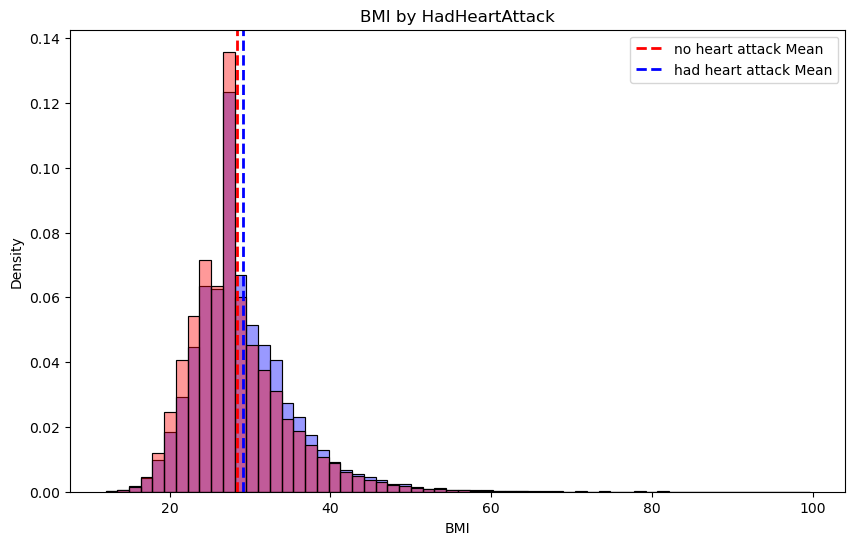

In [20]:
plot_hist_with_stats(
    data_imputed,
    value_col="BMI",
    hue_col="HadHeartAttack",
    bins=60
)

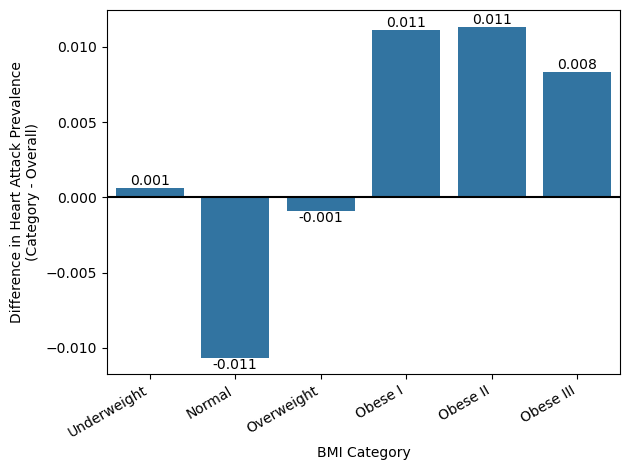

In [21]:
df = data_imputed.copy()
data_prop_ha = data_imputed["HadHeartAttack"].mean()

df["BMI_category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 35, 40, np.inf],
    labels=[
        "Underweight", "Normal", "Overweight",
        "Obese I", "Obese II", "Obese III"
    ]
)

prevalence = (
    df.groupby("BMI_category", observed=False)["HadHeartAttack"]
      .mean()
      .reset_index()
      .rename(columns={"HadHeartAttack": "category_rate"})
)

overall = data_imputed["HadHeartAttack"].mean()

prevalence["diff_vs_overall"] = prevalence["category_rate"] - overall
prevalence["pct_change_vs_overall"] = (
    (prevalence["category_rate"] - overall) / overall
) * 100

ax = sns.barplot(
    data=prevalence,
    x="BMI_category",
    y="diff_vs_overall",
)

ax.axhline(0, color="black")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=30, ha="right")

plt.ylabel("Difference in Heart Attack Prevalence\n(Category - Overall)")
plt.xlabel("BMI Category")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

# Models

In [30]:
# imports for modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, f1_score, average_precision_score,
                             precision_recall_curve, accuracy_score)



# models
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# hyperparameter tuning
from sklearn.model_selection import ParameterSampler

In [23]:
X = data_imputed.drop(columns=["HadHeartAttack"])
y = data_imputed["HadHeartAttack"]

# OHE categorical columns, StandardScaler numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), 
            continous_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), 
            ['State', 'Region', 'Sex', 'RaceEthnicityCategory', 'TetanusLast10Tdap']),
    ], 
    remainder="passthrough"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
])

X_OHE = pipeline.fit_transform(X)

feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

X_OHE = pd.DataFrame(
    X_OHE,
    columns=feature_names,
    index=X.index
)
X_OHE.head(5)

,num__PhysicalHealthDays,num__MentalHealthDays,num__SleepHours,num__HeightInMeters,num__WeightInKilograms,num__BMI,cat__State_AL,cat__State_AR,cat__State_AZ,cat__State_CA,...,remainder__AgeCategorymissing,remainder__HeightInMetersmissing,remainder__WeightInKilogramsmissing,remainder__BMImissing,remainder__AlcoholDrinkersmissing,remainder__HIVTestingmissing,remainder__FluVaxLast12missing,remainder__PneumoVaxEvermissing,remainder__HighRiskLastYearmissing,remainder__CovidPosmissing
0,-0.49153,-0.515488,0.656772,-0.024913,-0.103725,-0.156524,1.0,0.0,0.0,0.0,...,False,True,True,True,False,False,False,False,False,False
1,-0.49153,-0.515488,-0.687687,-0.98944,-0.725653,-0.296994,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,-0.258523,-0.154541,-1.359916,-1.278798,-0.94798,-0.451996,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,-0.49153,-0.515488,-0.015457,-0.507176,-0.94798,-0.824968,1.0,0.0,0.0,0.0,...,True,False,False,False,False,False,False,False,False,False
4,-0.258523,-0.515488,1.329001,-1.278798,-1.414181,-1.072001,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [24]:
def best_f1_thresold(y_test, y_test_prob):
    # Compute precision, recall, thresholds
    precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)

    # Compute F1 for each threshold
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
        precision[:-1] + recall[:-1]
    )

    # Best threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    return best_f1, best_threshold

## Native Bayes

In [25]:
def train_fit_test_NB(model, X, y=y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model.fit(X_train, y_train)

    y_test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_test_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_test_prob = y_test_pred
    
    c_mat = confusion_matrix(y_test, y_test_pred) 
    report = classification_report(y_test, y_test_pred) 
    roc_auc = roc_auc_score(y_test, y_test_prob) 
    best_f1, threshold = best_f1_thresold(y_test, y_test_pred)
    pr_auc = average_precision_score(y_test, y_test_prob)

    print("=== Test Set ===") 
    print(report) 
    print(f"Confusion Matrix:\n{c_mat}") 
    print(f"ROC-AUC Score: {roc_auc}") 
    print(f"F1 Score: {best_f1}, threshold = {threshold}")
    print(f"PR-AUC Score: {pr_auc}")  

    return roc_auc, c_mat, report

train_fit_test_NB(
    GaussianNB(),
    X_OHE.apply(pd.to_numeric)
)

=== Test Set ===
              precision    recall  f1-score   support

         0.0       0.98      0.83      0.90     83392
         1.0       0.19      0.65      0.29      5022

    accuracy                           0.82     88414
   macro avg       0.58      0.74      0.59     88414
weighted avg       0.93      0.82      0.86     88414

Confusion Matrix:
[[69161 14231]
 [ 1740  3282]]
ROC-AUC Score: 0.8121984548206617
F1 Score: 0.2912802307521633, threshold = 1.0
PR-AUC Score: 0.20154867134528687


(0.8121984548206617,
 array([[69161, 14231],
        [ 1740,  3282]]),
 '              precision    recall  f1-score   support\n\n         0.0       0.98      0.83      0.90     83392\n         1.0       0.19      0.65      0.29      5022\n\n    accuracy                           0.82     88414\n   macro avg       0.58      0.74      0.59     88414\nweighted avg       0.93      0.82      0.86     88414\n')

## Logistical Regression

### Logistic Regression with df (without much preprocessing)
- changed boolean columns to integers for modeling
- only selected numeric columns for modeling, dropped rows with missing values

In [56]:
imputed_df_numeric = data_imputed[continuous_cols + binary_cols].copy()
# bool_cols = imputed_df_numeric.select_dtypes(include='bool').columns
# imputed_df_numeric[bool_cols] = imputed_df_numeric[bool_cols].astype('Int64')
imputed_df_numeric['HadHeartAttack'] = imputed_df_numeric['HadHeartAttack'].astype('Int64')
imputed_df_numeric = imputed_df_numeric.select_dtypes(include='number')

imputed_df_numeric = imputed_df_numeric.dropna()


# Split features and target
X1 = imputed_df_numeric.drop(columns=['HadHeartAttack'])
y1 = imputed_df_numeric['HadHeartAttack']

# Train/val/test split (80/10/10)
X1_train, X1_temp, y1_train, y1_temp = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)
X1_val, X1_test, y1_val, y1_test = train_test_split(
    X1_temp, y1_temp, test_size=0.5, random_state=42, stratify=y1_temp
)

# Scale features
scaler1 = StandardScaler()
X1_train = scaler1.fit_transform(X1_train)
X1_val = scaler1.transform(X1_val)
X1_test = scaler1.transform(X1_test)

# Fit model
model1 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model1.fit(X1_train, y1_train)

# Evaluate on validation set
print("=== [Block 1] Validation Set ===")
y1_val_pred = model1.predict(X1_val)
y1_val_prob = model1.predict_proba(X1_val)[:, 1]
print(classification_report(y1_val, y1_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y1_val, y1_val_pred))
print("ROC-AUC Score:", roc_auc_score(y1_val, y1_val_prob))

print("_________________________________________________________________\n")

# Evaluate on test set
print("=== [Block 1] Test Set ===")
y1_test_pred = model1.predict(X1_test)
y1_test_prob = model1.predict_proba(X1_test)[:, 1]
print(classification_report(y1_test, y1_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y1_test, y1_test_pred))
print("ROC-AUC Score:", roc_auc_score(y1_test, y1_test_prob))

=== [Block 1] Validation Set ===
              precision    recall  f1-score   support

         0.0       0.98      0.86      0.91     41696
         1.0       0.22      0.68      0.33      2511

    accuracy                           0.85     44207
   macro avg       0.60      0.77      0.62     44207
weighted avg       0.94      0.85      0.88     44207

Confusion Matrix:
 [[35666  6030]
 [  794  1717]]
ROC-AUC Score: 0.8508916676065067
_________________________________________________________________

=== [Block 1] Test Set ===
              precision    recall  f1-score   support

         0.0       0.98      0.86      0.92     41696
         1.0       0.23      0.70      0.35      2511

    accuracy                           0.85     44207
   macro avg       0.60      0.78      0.63     44207
weighted avg       0.94      0.85      0.88     44207

Confusion Matrix:
 [[35854  5842]
 [  759  1752]]
ROC-AUC Score: 0.860382801857552


### Logistic Regression with data_imputed (after preprocessing)

In [57]:
# LOGISTIC REGRESSION with data_imputed (and cleaned)
X2 = data_imputed.drop(columns=['HadHeartAttack']).select_dtypes(include=['float64', 'number'])
y2 = data_imputed['HadHeartAttack']

# Train/val/test split (80/10/10)
X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.5, random_state=42, stratify=y2_temp
)

# Scale features
scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_val = scaler2.transform(X2_val)
X2_test = scaler2.transform(X2_test)

# Fit model
model2 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model2.fit(X2_train, y2_train)

# Evaluate on validation set
print("=== [Block 2] Validation Set ===")
y2_val_pred = model2.predict(X2_val)
y2_val_prob = model2.predict_proba(X2_val)[:, 1]
print(classification_report(y2_val, y2_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y2_val, y2_val_pred))
print("ROC-AUC Score:", roc_auc_score(y2_val, y2_val_prob))

print("_________________________________________________________________\n")

# Evaluate on test set
print("=== [Block 2] Test Set ===")
y2_test_pred = model2.predict(X2_test)
y2_test_prob = model2.predict_proba(X2_test)[:, 1]
print(classification_report(y2_test, y2_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y2_test, y2_test_pred))
print("ROC-AUC Score:", roc_auc_score(y2_test, y2_test_prob))

=== [Block 2] Validation Set ===
              precision    recall  f1-score   support

         0.0       0.98      0.83      0.90     41696
         1.0       0.21      0.75      0.33      2511

    accuracy                           0.83     44207
   macro avg       0.60      0.79      0.61     44207
weighted avg       0.94      0.83      0.87     44207

Confusion Matrix:
 [[34667  7029]
 [  630  1881]]
ROC-AUC Score: 0.8772144792383962
_________________________________________________________________

=== [Block 2] Test Set ===
              precision    recall  f1-score   support

         0.0       0.98      0.84      0.90     41696
         1.0       0.22      0.75      0.34      2511

    accuracy                           0.83     44207
   macro avg       0.60      0.79      0.62     44207
weighted avg       0.94      0.83      0.87     44207

Confusion Matrix:
 [[34854  6842]
 [  620  1891]]
ROC-AUC Score: 0.8817673552562127


## CatBoost

In [35]:
def train_fit_test_CB(model, X, y=y, cat_features=None): 
    if cat_features is None: 
        cat_features = (X.select_dtypes('category').columns.values).tolist() 
    X_train, X_test, y_train, y_test = train_test_split( 
        X, y, 
        test_size=0.2, # 80/20 split 
        random_state=42, # reproducibility 
        stratify=y # preserve class proportions 
    ) # IMPORTANT: create validation split for early stopping 
    X_train2, X_val, y_train2, y_val = train_test_split( 
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train 
    ) 
    
    model.fit(
        X_train2, y_train2, 
        cat_features=cat_features, 
        eval_set=(X_val, y_val), 
        use_best_model=True
    ) 
    y_test_pred = model.predict(X_test) # Handle models whose predict returns probabilities differently 
    if hasattr(model, "predict_proba"): 
        y_test_prob = model.predict_proba(X_test)[:, 1] 
    else: 
        y_test_prob = model.predict(X_test) 
    
    c_mat = confusion_matrix(y_test, y_test_pred) 
    report = classification_report(y_test, y_test_pred) 
    roc_auc = roc_auc_score(y_test, y_test_prob) 
    f1, threshold = best_f1_thresold(y_test, y_test_pred)
    pr_auc = average_precision_score(y_test, y_test_prob)

    print("=== Test Set ===") 
    print(report) 
    print(f"Confusion Matrix:\n{c_mat}") 
    print(f"ROC-AUC Score: {roc_auc}") 
    print(f"F1 Score: {f1}, threshold = {threshold}")
    print(f"PR-AUC Score: {pr_auc}")  
    return model, c_mat, roc_auc, report

train_fit_test_CB(CatBoostClassifier(
        auto_class_weights="Balanced",
        iterations=5000,   # set high upper bound
        depth=6,
        learning_rate=0.05,
        early_stopping_rounds=50,
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    ),
    X, 
    cat_features= ['State', 'Sex', 'RaceEthnicityCategory', 'TetanusLast10Tdap', 'Region']
)

=== Test Set ===
              precision    recall  f1-score   support

         0.0       0.98      0.83      0.90     83392
         1.0       0.21      0.78      0.34      5022

    accuracy                           0.82     88414
   macro avg       0.60      0.80      0.62     88414
weighted avg       0.94      0.82      0.87     88414

Confusion Matrix:
[[69002 14390]
 [ 1110  3912]]
ROC-AUC Score: 0.8905018537200706
F1 Score: 0.3354484651003259, threshold = 1.0
PR-AUC Score: 0.43056245551752637


(CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=5000, learning_rate=0.05, random_seed=42, verbose=False),
 array([[69002, 14390],
        [ 1110,  3912]]),
 0.8905018537200706,
 '              precision    recall  f1-score   support\n\n         0.0       0.98      0.83      0.90     83392\n         1.0       0.21      0.78      0.34      5022\n\n    accuracy                           0.82     88414\n   macro avg       0.60      0.80      0.62     88414\nweighted avg       0.94      0.82      0.87     88414\n')

In [39]:
# hyper parameter tuning
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

def train_fit_test_CB_fixed(model, X_train2, y_train2, X_val, 
                            y_val, X_test, y_test, cat_features):

    model.fit(
        X_train2, y_train2,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # Compute precision, recall, thresholds
    precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)

    # Compute F1 for each threshold
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
        precision[:-1] + recall[:-1]
    )

    # Best threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    c_mat = confusion_matrix(y_test, y_test_pred) 
    report = classification_report(y_test, y_test_pred) 

    roc_auc = roc_auc_score(y_test, y_test_prob)
    pr_auc = average_precision_score(y_test, y_test_prob)

    return roc_auc, best_f1, pr_auc, best_threshold, c_mat, report

param_dist = {
    "depth": [4, 5, 6, 7, 8],
    "learning_rate": np.linspace(0.03, 0.1, 5),
    "l2_leaf_reg": [1, 3, 5, 7, 9]
}

samples = list(ParameterSampler(param_dist, n_iter=15, random_state=42))

# loop thru to find best parameters in samples --> not worth it, score doesn't improve
best_score = 0
best_params = None
scores = []

for param in samples:
    d = param["depth"]
    l = param["learning_rate"]
    reg = param["l2_leaf_reg"]

    model = CatBoostClassifier(
        auto_class_weights="Balanced",
        iterations=5000,
        depth=d,
        learning_rate=l,
        l2_leaf_reg=reg,
        early_stopping_rounds=50,
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    )

    roc_auc, f1, pr_auc, threshold, c_mat, report = train_fit_test_CB_fixed(
        model,
        X_train2, y_train2,
        X_val, y_val,
        X_test, y_test,
        cat_features=['State','Sex','RaceEthnicityCategory','TetanusLast10Tdap','Region']
    )

    score = sum([roc_auc, f1, pr_auc])

    if score > best_score:
        print("*********** NEW BEST SCORE ***********")
        best_score = score
        best_params = (d, l, reg)
    else:
        print("=====================================")
    print(f"depth = {d}, learning rate = {l}, l2_leaf_reg = {reg}, threshold = {threshold}")
    print(f"ROC-AUC Score: {roc_auc}")
    print(f"F1 Score: {f1}")
    print(f"PR-AUC Score: {pr_auc}")  
print(best_score, best_params)

*********** NEW BEST SCORE ***********
depth = 4, learning rate = 0.0825, l2_leaf_reg = 7, threshold = 0.8523787335813737
ROC-AUC Score: 0.8902684099402384
F1 Score: 0.48578957274609447
PR-AUC Score: 0.42830431279640463
*********** NEW BEST SCORE ***********
depth = 5, learning rate = 0.065, l2_leaf_reg = 7, threshold = 0.8425094951594352
ROC-AUC Score: 0.8904907289354316
F1 Score: 0.48564017046507324
PR-AUC Score: 0.4289642388340824
*********** NEW BEST SCORE ***********
depth = 5, learning rate = 0.0475, l2_leaf_reg = 5, threshold = 0.8540327985700833
ROC-AUC Score: 0.8904373925296616
F1 Score: 0.48732021196063585
PR-AUC Score: 0.42895920865458975
depth = 7, learning rate = 0.0475, l2_leaf_reg = 1, threshold = 0.8173262899107934
ROC-AUC Score: 0.890100621253438
F1 Score: 0.48563968668407315
PR-AUC Score: 0.4297847030303302
depth = 6, learning rate = 0.0825, l2_leaf_reg = 1, threshold = 0.8358115720284338
ROC-AUC Score: 0.8901376155201075
F1 Score: 0.4868941414513014
PR-AUC Score: 0.4

In [58]:
# hyperparamter tuned best model
train_fit_test_CB(CatBoostClassifier(
        auto_class_weights="Balanced",
        iterations=5000,   # set high upper bound
        depth=6,
        learning_rate=0.0475,
        l2_leaf_reg = 7,
        early_stopping_rounds=50,
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    ),
    X, 
    cat_features= ['State', 'Sex', 'RaceEthnicityCategory', 'TetanusLast10Tdap', 'Region']
)

=== Test Set ===
              precision    recall  f1-score   support

         0.0       0.98      0.83      0.90     83392
         1.0       0.21      0.78      0.34      5022

    accuracy                           0.82     88414
   macro avg       0.60      0.80      0.62     88414
weighted avg       0.94      0.82      0.87     88414

Confusion Matrix:
[[69031 14361]
 [ 1113  3909]]
ROC-AUC Score: 0.890509936440827
F1 Score: 0.33565172591447706, threshold = 1.0
PR-AUC Score: 0.4301419037933345


(CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=5000, l2_leaf_reg=7, learning_rate=0.0475, random_seed=42, verbose=False),
 array([[69031, 14361],
        [ 1113,  3909]]),
 0.890509936440827,
 '              precision    recall  f1-score   support\n\n         0.0       0.98      0.83      0.90     83392\n         1.0       0.21      0.78      0.34      5022\n\n    accuracy                           0.82     88414\n   macro avg       0.60      0.80      0.62     88414\nweighted avg       0.94      0.82      0.87     88414\n')

CatBoost acheives the exact same precision, recall, ROC-AUC scores with and without hyperparameter tuning so tuning does not have a big effect on model ability

## Random Forest Classifier

### Random Forest Classifier #1 with Pre-Processed Data after OHE and Imputation

In [37]:
# Train/val/test split (80/10/10)
X3 = data_imputed.drop(columns=["HadHeartAttack"])
y3 = data_imputed["HadHeartAttack"]  # also remove double brackets, RF expects 1D array

# OHE categorical columns, StandardScaler numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), 
            ['State', 'Region', 'Sex', 'RaceEthnicityCategory', 'TetanusLast10Tdap']),
    ], 
    remainder="passthrough"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
])

X_OHE = pipeline.fit_transform(X3)  

feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()
X_OHE = pd.DataFrame(X_OHE, 
                     columns=feature_names, 
                     index=X3.index)

X_OHE.head(5)

X3_train, X3_temp, y3_train, y3_temp = train_test_split(
    X_OHE, y3, test_size=0.2, random_state=42, stratify=y3  
)
X3_val, X3_test, y3_val, y3_test = train_test_split(
    X3_temp, y3_temp, test_size=0.5, random_state=42, stratify=y3_temp
)

# Fit Random Forest model
model3 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model3.fit(X3_train, y3_train)

# Evaluate on validation set
print("=== [Block 3] Validation Set ===")
y3_val_pred = model3.predict(X3_val)
y3_val_prob = model3.predict_proba(X3_val)[:, 1]
print(classification_report(y3_val, y3_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y3_val, y3_val_pred))
print("ROC-AUC Score:", roc_auc_score(y3_val, y3_val_prob))

print("_________________________________________________________________\n")

# Evaluate on test set
print("=== [Block 3] Test Set ===")
y3_test_pred = model3.predict(X3_test)
y3_test_prob = model3.predict_proba(X3_test)[:, 1]
print(classification_report(y3_test, y3_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y3_test, y3_test_pred))
print("ROC-AUC Score:", roc_auc_score(y3_test, y3_test_prob))

=== [Block 3] Validation Set ===
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97     41696
         1.0       0.61      0.12      0.20      2511

    accuracy                           0.95     44207
   macro avg       0.78      0.56      0.59     44207
weighted avg       0.93      0.95      0.93     44207

Confusion Matrix:
 [[41501   195]
 [ 2202   309]]
ROC-AUC Score: 0.8736489893432825
_________________________________________________________________

=== [Block 3] Test Set ===
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97     41696
         1.0       0.61      0.12      0.20      2511

    accuracy                           0.95     44207
   macro avg       0.78      0.56      0.59     44207
weighted avg       0.93      0.95      0.93     44207

Confusion Matrix:
 [[41501   195]
 [ 2206   305]]
ROC-AUC Score: 0.8770857669844396


### Random Forest Classifier #2 with Same Pre-Processed Data after OHE and Imputation BUT with Hyperparameter Tuning
- from the last RF classifier, we lowered the classification threshold to improve recall on the positive class
(instead of the default 0.5, the optimal threshold is found uing the validation set, then applied to test set)

The key changes made are listed below:
- Threshold tuning — sweeps thresholds from 0.1 to 0.6 on the validation set and picks the one that maximizes F1 on the positive class. A lower threshold means the model flags more people as having had a heart attack, boosting recall at the cost of some level of precision.
- the threshold is chosen on validation and applied blindly to the test set
- set parameter n_jobs = -1, which uses all CPU cores to speed up training.

In [ ]:
# Train/val/test split (80/10/10)
X3_train, X3_temp, y3_train, y3_temp = train_test_split(
    X_OHE, y3, test_size=0.2, random_state=42, stratify=y3
)
X3_val, X3_test, y3_val, y3_test = train_test_split(
    X3_temp, y3_temp, test_size=0.5, random_state=42, stratify=y3_temp
)

# Fit Random Forest model
model3 = RandomForestClassifier(n_estimators=100, class_weight='balanced', 
                                n_jobs=-1, random_state=42)
model3.fit(X3_train, y3_train)

# --- Find optimal threshold using validation set ---
y3_val_prob = model3.predict_proba(X3_val)[:, 1]

from sklearn.metrics import f1_score
thresholds = np.arange(0.1, 0.6, 0.05)
best_threshold = 0.5
best_f1 = 0
f1s = []

for t in thresholds:
    y_pred_t = (y3_val_prob >= t).astype(int)
    f1 = f1_score(y3_val, y_pred_t)
    f1s += []
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Optimal Threshold: {best_threshold:.2f} | Best Validation F1: {best_f1:.4f}\n")

# --- Evaluate on validation set with optimal threshold ---
print("=== [Block 3] Validation Set ===")
y3_val_pred = (y3_val_prob >= best_threshold).astype(int)
print(classification_report(y3_val, y3_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y3_val, y3_val_pred))
print("ROC-AUC Score:", roc_auc_score(y3_val, y3_val_prob))

print("_________________________________________________________________\n")

# --- Evaluate on test set with optimal threshold ---
print("=== [Block 3] Test Set ===")
y3_test_prob = model3.predict_proba(X3_test)[:, 1]
y3_test_pred = (y3_test_prob >= best_threshold).astype(int)
print(classification_report(y3_test, y3_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y3_test, y3_test_pred))
print("ROC-AUC Score:", roc_auc_score(y3_test, y3_test_prob))

Optimal Threshold: 0.20 | Best Validation F1: 0.4709

=== [Block 3] Validation Set ===
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.96     41696
         1.0       0.43      0.53      0.47      2511

    accuracy                           0.93     44207
   macro avg       0.70      0.74      0.72     44207
weighted avg       0.94      0.93      0.94     44207

Confusion Matrix:
 [[39924  1772]
 [ 1192  1319]]
ROC-AUC Score: 0.8736489893432825
_________________________________________________________________

=== [Block 3] Test Set ===
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.96     41696
         1.0       0.43      0.53      0.47      2511

    accuracy                           0.93     44207
   macro avg       0.70      0.74      0.72     44207
weighted avg       0.94      0.93      0.94     44207

Confusion Matrix:
 [[39918  1778]
 [ 1176  1335]]
ROC-AUC Score: 0.87708576698443

After performing the key changes noted above, we can see from the results that the F1-score on the positive class jumped from a 20% to a 47% (almost double), which is a substaintial gain. Looking at the precision and recall values, there is also a much better balance between them compared to our baselines using logisitic regression and also the first random forest model. 
- Recall improved from 0.12 to 0.54 -> it now catches over half of actual heart attack cases
- Precision held at 0.42, a major improvement over logistic regression's 0.22

ROC AUC stands for Receiver Operating Characteristic Area Under the Curve. It is a standard performance metric used in machine learning and statistics to evaluate how well a classification model can distinguish between different classes (e.g., whether an email is spam or not spam). In this case, our ROC AUC is approximately 87%, which is considered clinically useful for a heart attack risk predictor. It indicates that the model has a good ability to differentiate between patients who have had a heart attack and those who have not. A value of 1.0 indicates perfect discrimination. AUC values above 0.80 are generally consideredclinically useful, while values below 0.80 are considered of limited clinical utility. (https://pmc.ncbi.nlm.nih.gov/articles/PMC10664195/)

Validation and test results are nearly identical, confirming the model generalizes well and is not overfitting to the validation set or training set. 